In [1]:
import yfinance as yf



In [2]:
ticker = yf.Ticker("AAPL")
print(ticker.info)

{'address1': 'One Apple Park Way', 'city': 'Cupertino', 'state': 'CA', 'zip': '95014', 'country': 'United States', 'phone': '(408) 996-1010', 'website': 'https://www.apple.com', 'industry': 'Consumer Electronics', 'industryKey': 'consumer-electronics', 'industryDisp': 'Consumer Electronics', 'sector': 'Technology', 'sectorKey': 'technology', 'sectorDisp': 'Technology', 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and

In [3]:
history = ticker.history(period="1y")
history

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-02-14 00:00:00-05:00,240.203075,244.484418,239.944209,243.538544,40896200,0.00,0.0
2025-02-18 00:00:00-05:00,243.090500,244.116029,240.790527,243.409119,48822500,0.00,0.0
2025-02-19 00:00:00-05:00,243.598293,244.942425,242.104802,243.807373,32204200,0.00,0.0
2025-02-20 00:00:00-05:00,243.877077,245.709089,243.229888,244.763214,32316900,0.00,0.0
2025-02-21 00:00:00-05:00,244.882694,247.610809,244.155866,244.484436,53197400,0.00,0.0
...,...,...,...,...,...,...,...
2026-02-09 00:00:00-05:00,277.910004,278.200012,271.700012,274.619995,44623400,0.26,0.0
2026-02-10 00:00:00-05:00,274.890015,275.369995,272.940002,273.679993,34376900,0.00,0.0
2026-02-11 00:00:00-05:00,274.700012,280.179993,274.450012,275.500000,51931300,0.00,0.0


In [4]:
history = ticker.history(period="10y")
history

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-02-16 00:00:00-05:00,21.520175,21.934634,21.427318,21.887074,196231600,0.00,0.0
2016-02-17 00:00:00-05:00,21.893866,22.242646,21.776097,22.222263,179452800,0.00,0.0
2016-02-18 00:00:00-05:00,22.385328,22.396653,21.762507,21.801010,156084000,0.00,0.0
2016-02-19 00:00:00-05:00,21.742127,21.914253,21.696832,21.751186,141496800,0.00,0.0
2016-02-22 00:00:00-05:00,21.812339,21.945964,21.724012,21.941433,137123200,0.00,0.0
...,...,...,...,...,...,...,...
2026-02-09 00:00:00-05:00,277.910004,278.200012,271.700012,274.619995,44623400,0.26,0.0
2026-02-10 00:00:00-05:00,274.890015,275.369995,272.940002,273.679993,34376900,0.00,0.0
2026-02-11 00:00:00-05:00,274.700012,280.179993,274.450012,275.500000,51931300,0.00,0.0


<Axes: title={'center': 'AAPL Closing Price'}, xlabel='Date'>

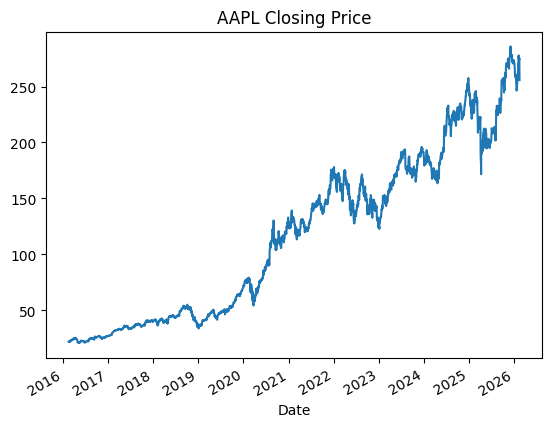

In [5]:
history['Close'].plot(title="AAPL Closing Price")

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def preprocess_for_qlearning(history, 
                             return_bins=10, 
                             vol_bins=10, 
                             ma_bins=10,
                             ma_short=5,
                             ma_long=20,
                             vol_window=10):

    df = pd.DataFrame()
    
    

    df['log_return'] = np.log(history['Close'] / history['Close'].shift(1))
    

    df['ma_short'] = history['Close'].rolling(ma_short).mean()
    df['ma_long'] = history['Close'].rolling(ma_long).mean()
    

    df['ma_ratio'] = df['ma_short'] / df['ma_long']
    

    df['volatility'] = df['log_return'].rolling(vol_window).std()
    

    df = df.dropna().reset_index(drop=True)
    

    features = ['log_return', 'ma_ratio', 'volatility']
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    

    df['ret_bin'] = pd.qcut(df['log_return'], return_bins, labels=False)
    df['ma_bin'] = pd.qcut(df['ma_ratio'], ma_bins, labels=False)
    df['vol_bin'] = pd.qcut(df['volatility'], vol_bins, labels=False)
    

    df['state'] = (
        df['ret_bin'] * (ma_bins * vol_bins) +
        df['ma_bin'] * vol_bins +
        df['vol_bin']
    )
    
    n_states = return_bins * ma_bins * vol_bins
    
    return df, n_states, scaler


Total states: 1000
                           state
Date                            
2016-02-16 00:00:00-05:00    NaN
2016-02-17 00:00:00-05:00    NaN
2016-02-18 00:00:00-05:00    NaN
2016-02-19 00:00:00-05:00    NaN
2016-02-22 00:00:00-05:00    NaN


<Axes: xlabel='Date'>

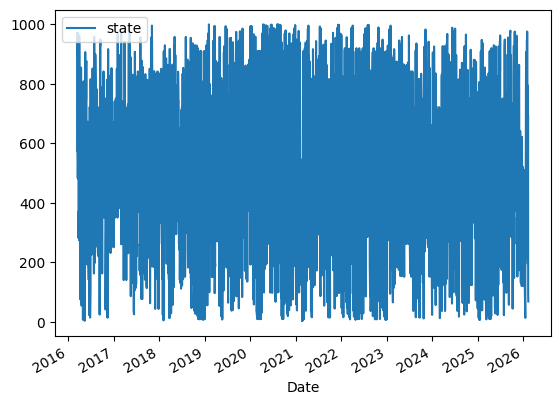

In [7]:
df, n_states, scaler = preprocess_for_qlearning(history)
df.index = history.index[-len(df):]
df = df.reindex(history.index)
print("Total states:", n_states)
print(df[['state']].head())
df[['state']].plot()

In [8]:
import numpy as np
train_index = int(len(history) * 0.8)
days_window = 5
states = {"cash": 10000, "volume": 0, "price": history["Close"].iloc[train_index], "time": history.index[train_index], "history": df['state'].iloc[train_index-days_window:train_index].tolist()} # last (days_window) days of closing prices
actions = [0,1,2] # 0: hold, 1: buy, 2: sell
actions1 = np.arange(1, 10) # buy/sell 1, 2, ..., 9 shares 

In [9]:
def reward(prev_state, next_state, action):
    if prev_state["volume"] == 0 and action == 2:
        return -10  # Penalty for selling without position
    if prev_state["cash"] < prev_state["price"] and action == 1:
        return -10  # Penalty for buying without cash
    prev_value = prev_state["cash"] + prev_state["volume"] * prev_state["price"]
    next_value = next_state["cash"] + next_state["volume"] * next_state["price"]
    return next_value - prev_value


In [10]:
def step(state, action, index, history):
    price = history["Close"].iloc[index] # current price
    revenue = 0
    if action == 0: # hold
        revenue = 0
    elif action == 1: # buy
        shares_to_buy = min(state["cash"] // price, 9) # can only buy up to 9 shares
        cost = shares_to_buy * price
        state["cash"] -= cost
        state["volume"] += shares_to_buy
        revenue = -cost
    elif action == 2: # sell
        shares_to_sell = min(state["volume"], 9) # can only sell up to 9 shares
        revenue = shares_to_sell * price
        state["cash"] += revenue
        state["volume"] -= shares_to_sell
    state = {
        "cash": state["cash"],
        "volume": state["volume"],
        "price": history["Close"].iloc[index+1], # next price
        "time": history.index[index+1],
        "history": df['state'].iloc[index-days_window+1:index+1].tolist() # last (days_window) days of closing prices
    }
    return state, revenue

In [11]:
import random
from tqdm import tqdm
import numpy as np

def Q_learning(num_episodes=1000, gamma=0.9, epsilon=1.0, decay_rate=0.999):

    Q_table = {}
    update_counts = {}

    for episode in tqdm(range(num_episodes)):

        initial_index = random.randint(days_window, train_index-1)

        state = {
            "cash": 10000,
            "volume": 0,
            "price": history["Close"].iloc[initial_index],
            "time": history.index[initial_index]
        }

        done = False

        while not done:

            index = history.index.get_loc(state["time"])

            if index >= len(history) - 1:
                break

            market_state = df['state'].iloc[index]
            position = int(np.sign(state["volume"]))
            state_key = (market_state, position)

            if state_key not in Q_table:
                Q_table[state_key] = np.zeros(len(actions))
                update_counts[state_key] = np.zeros(len(actions))

            if np.random.rand() < epsilon:
                action = np.random.choice(actions)
            else:
                action = np.argmax(Q_table[state_key])


            next_state, _ = step(state.copy(), action, index, history)


            reward_value = reward(state, next_state, action)

            next_index = history.index.get_loc(next_state["time"])
            next_market_state = df['state'].iloc[next_index]
            next_position = int(np.sign(next_state["volume"]))
            next_state_key = (next_market_state, next_position)

            if next_state_key not in Q_table:
                Q_table[next_state_key] = np.zeros(len(actions))
                update_counts[next_state_key] = np.zeros(len(actions))


            update_counts[state_key][action] += 1
            eta = 1.0 / update_counts[state_key][action]


            Q_table[state_key][action] += eta * (
                reward_value
                + gamma * np.max(Q_table[next_state_key])
                - Q_table[state_key][action]
            )

            state = next_state

        epsilon *= decay_rate

    return Q_table


In [12]:
import pickle

decay_rate = 0.999

Q_table = Q_learning(num_episodes=1000, gamma=0.9, epsilon=1, decay_rate=decay_rate) # Run Q-learning

# Save the Q-table dict to a file
with open('Q_table.pickle', 'wb') as handle:
    pickle.dump(Q_table, handle, protocol=pickle.HIGHEST_PROTOCOL)

100%|██████████| 1000/1000 [02:07<00:00,  7.85it/s]


In [13]:
import pickle
import numpy as np

with open('Q_table.pickle', 'rb') as f:
    Q_table = pickle.load(f)

initial_index = train_index + 1
days_to_simulate = 240
state = {
    "cash": 10000,
    "volume": 0,
    "price": history["Close"].iloc[initial_index],
    "time": history.index[initial_index]
}
reward_history = []

for t in range(days_to_simulate):

    index = history.index.get_loc(state["time"])

    if index >= len(history) - 1:
        break

    market_state = df['state'].iloc[index]
    position = int(np.sign(state["volume"]))
    state_key = (market_state, position)

    if state_key in Q_table:
        action = np.argmax(Q_table[state_key])
    else:
        action = 0  # hold if unseen

    print(f"Day {t+1}: Action: {action}, "
          f"Cash: {state['cash']:.2f}, "
          f"Volume: {state['volume']}, "
          f"Price: {state['price']:.2f}")

    next_state, _ = step(state.copy(), action, index, history)
    reward_history.append(next_state["cash"] + next_state["volume"] * next_state["price"])

    state = next_state

# Final portfolio value
final_value = state["cash"] + state["volume"] * state["price"]
print("Final portfolio value:", final_value)


Day 1: Action: 0, Cash: 10000.00, Volume: 0, Price: 182.49
Day 2: Action: 0, Cash: 10000.00, Volume: 0, Price: 182.20
Day 3: Action: 0, Cash: 10000.00, Volume: 0, Price: 180.67
Day 4: Action: 0, Cash: 10000.00, Volume: 0, Price: 179.92
Day 5: Action: 0, Cash: 10000.00, Volume: 0, Price: 180.68
Day 6: Action: 0, Cash: 10000.00, Volume: 0, Price: 182.71
Day 7: Action: 0, Cash: 10000.00, Volume: 0, Price: 180.87
Day 8: Action: 0, Cash: 10000.00, Volume: 0, Price: 179.53
Day 9: Action: 0, Cash: 10000.00, Volume: 0, Price: 180.98
Day 10: Action: 0, Cash: 10000.00, Volume: 0, Price: 179.78
Day 11: Action: 0, Cash: 10000.00, Volume: 0, Price: 179.12
Day 12: Action: 0, Cash: 10000.00, Volume: 0, Price: 178.04
Day 13: Action: 0, Cash: 10000.00, Volume: 0, Price: 173.52
Day 14: Action: 0, Cash: 10000.00, Volume: 0, Price: 168.59
Day 15: Action: 1, Cash: 10000.00, Volume: 0, Price: 167.59
Day 16: Action: 1, Cash: 8491.65, Volume: 9, Price: 167.48
Day 17: Action: 1, Cash: 6984.36, Volume: 18, Pric

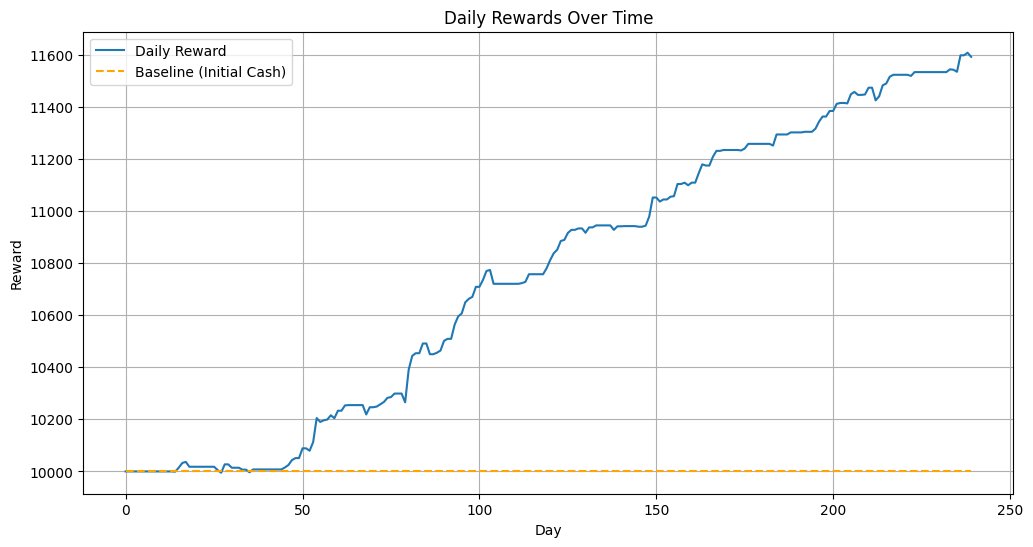

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(reward_history, label='Daily Reward')
plt.plot(np.arange(len(reward_history)), [10000]*len(reward_history), label='Baseline (Initial Cash)', linestyle='--', color='orange')
plt.xlabel('Day')
plt.ylabel('Reward')
plt.title('Daily Rewards Over Time')
plt.legend()
plt.grid()
